# AICE Associate 대비 실습 과정 — 3회차
## 데이터 이해하기 (탐색적 데이터 분석, EDA)

> **과정 구성**: 총 8회 × 3시간, 실습 위주  
> **선수 학습**: 1·2회차. `data/customers.csv`, `data/sales_2024.csv` 를 계속 사용하고, 회귀 타깃 연습용으로 scikit-learn 내장 당뇨병 데이터를 추가합니다.

### 전체 커리큘럼

| 회차 | 주제 | 핵심 키워드 |
|:---:|------|------------|
| 1 | AI/ML/DL 개요, 데이터 획득하기 | AI ⊃ ML ⊃ DL, 지도/비지도, `read_csv`, `read_excel`, `to_csv` |
| 2 | 데이터 구조 확인하기, 기초 데이터 다루기 | `info`, `describe`, `loc/iloc`, 필터링, 정렬, `groupby`, `merge` |
| **3** | **데이터 이해하기 (EDA)** | 분포, 상관관계, `matplotlib`, `seaborn`, 가설 검증 |
| 4 | 데이터 전처리하기 | 결측치, 이상치, 구간화, 인코딩, 스케일링, `train_test_split` |
| 5 | AI 모델링 필수 개념, 지도학습 I | 과적합, 평가지표, 선형회귀, 로지스틱 회귀 |
| 6 | 지도학습 II | 의사결정나무, 앙상블, 랜덤포레스트, 그라디언트부스팅 |
| 7 | 인공신경망, 심층신경망, 딥러닝 프레임워크 | 퍼셉트론, 활성화함수, Keras `Sequential`, `EarlyStopping` |
| 8 | 비지도학습, 모델 성능 향상시키기 | K-Means, PCA, 교차검증, 하이퍼파라미터 튜닝, 모의고사 |

### 오늘의 학습 목표

1. EDA 의 목적과 순서(단변량 → 이변량 → 타깃 중심 → 가설)를 설명할 수 있다.
2. `matplotlib` 의 기본 구조(figure, axes)를 이해하고 제목·축·범례를 붙일 수 있다.
3. 변수 타입(수치형/범주형)에 따라 **알맞은 그래프를 고를 수 있다**.
4. 히스토그램·박스플롯으로 분포의 치우침과 이상치를 읽어낼 수 있다.
5. 산점도·상관계수·히트맵으로 변수 간 관계를 확인하고, 상관과 인과를 구별할 수 있다.
6. 타깃(`이탈여부`, `target`)과 각 변수의 관계를 그림으로 확인하고, 전처리·모델링에 쓸 **가설** 을 세울 수 있다.

### 시간 계획 (180분)

| 시간 | 내용 |
|------|------|
| 00:00 ~ 00:10 | 0. 환경 준비, 데이터 불러오기 |
| 00:10 ~ 00:30 | 1. EDA 란 무엇인가, matplotlib 기본 문법 |
| 00:30 ~ 01:15 | 2. 단변량 분석 |
| 01:15 ~ 01:25 | 휴식 |
| 01:25 ~ 02:25 | 3. 이변량 · 타깃 중심 · 시계열 분석 |
| 02:25 ~ 02:35 | 휴식 |
| 02:35 ~ 03:00 | 4. 가설 세우기, 5. 종합 실습, 정리 |

---
## 0. 환경 준비, 데이터 불러오기

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

DATA_DIR = "data"
print("pandas", pd.__version__, "| seaborn", sns.__version__)

pandas 2.2.1 | seaborn 0.13.2


In [2]:
# 한글 폰트 설정 (1회차와 동일). Colab 은 나눔폰트 설치 후 런타임 재시작 필요.
#   !apt-get -qq install fonts-nanum
#   !rm -rf ~/.cache/matplotlib
from matplotlib import font_manager


def set_korean_font() -> str:
  candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic"]
  installed = {f.name for f in font_manager.fontManager.ttflist}
  for name in candidates:
    if name in installed:
      plt.rcParams["font.family"] = name
      plt.rcParams["axes.unicode_minus"] = False
      return name
  plt.rcParams["axes.unicode_minus"] = False
  return "(한글 폰트 없음 - 그래프의 한글이 깨질 수 있음)"


print("적용된 폰트:", set_korean_font())

# seaborn 테마: 폰트 설정 뒤에 호출해야 폰트가 유지된다
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"][0], rc={"axes.unicode_minus": False})

적용된 폰트: AppleGothic


In [3]:
# ===== 1회차 실습 데이터가 없을 때만 재생성 (실행만 하면 됩니다) =====
def ensure_session1_data(data_dir: str = DATA_DIR) -> None:
  required = ["customers.csv", "sales_2024.csv"]
  if all(os.path.exists(f"{data_dir}/{f}") for f in required):
    print("1회차 데이터 확인 완료:", required)
    return

  os.makedirs(data_dir, exist_ok=True)
  rng = np.random.default_rng(42)
  n = 300
  regions = ["서울", "경기", "부산", "대구", "기타"]
  plans = ["5G", "LTE", "3G"]

  # 데이터 사용량: 일반 사용자(90%)는 평균 12GB·표준편차 4GB 의 종 모양(정규분포)으로,
  #               헤비 유저(10%)는 30~70GB 사이에서 고르게(균등분포) 만든다.
  #               -> 대부분은 10GB 안팎이고 소수만 큰 값을 가지는, 오른쪽 꼬리가 긴 분포가 된다.
  is_heavy = rng.random(n) < 0.10                                    # 행마다 10% 확률로 헤비 유저
  usage = np.where(is_heavy, rng.uniform(30, 70, size=n), rng.normal(12, 4, size=n))
  usage = np.clip(usage, 0.5, None)                                  # 음수 방지: 최소 0.5GB
  customers = pd.DataFrame({
    "고객ID": [f"C{i:04d}" for i in range(1, n + 1)],
    "성별": rng.choice(["M", "F"], size=n),
    "나이": rng.integers(19, 70, size=n).astype(float),
    "지역": rng.choice(regions, size=n, p=[0.35, 0.3, 0.15, 0.1, 0.1]),
    "우편번호": [f"{z:05d}" for z in rng.integers(1000, 63999, size=n)],
    "요금제": rng.choice(plans, size=n, p=[0.5, 0.4, 0.1]),
    "월요금": rng.choice([29000, 35000, 45000, 55000, 65000, 79000, 89000], size=n).astype(float),
    "데이터사용량": np.round(usage, 1),
    "가입일": pd.to_datetime("2019-01-01") + pd.to_timedelta(rng.integers(0, 2000, size=n), unit="D"),
  })
  customers["가입개월수"] = ((pd.to_datetime("2024-12-31") - customers["가입일"]).dt.days // 30)
  churn_prob = 0.15 + 0.25 * (customers["가입개월수"] < 12) + 0.1 * (customers["요금제"] == "3G")
  customers["이탈여부"] = np.where(rng.random(n) < churn_prob, "Yes", "No")
  customers.loc[rng.choice(n, 12, replace=False), "나이"] = np.nan
  customers.loc[rng.choice(n, 8, replace=False), "데이터사용량"] = np.nan
  customers.to_csv(f"{data_dir}/customers.csv", index=False)

  plan_info = pd.DataFrame({"요금제": plans, "속도Mbps": [1000, 150, 10], "출시연도": [2019, 2011, 2006]})
  with pd.ExcelWriter(f"{data_dir}/customers.xlsx") as writer:
    customers.to_excel(writer, sheet_name="customers", index=False)
    plan_info.to_excel(writer, sheet_name="plans", index=False)

  dates = pd.date_range("2024-01-01", "2024-12-31", freq="D")
  sales = pd.DataFrame({
    "날짜": np.repeat(dates, 3),
    "매장": np.tile(["강남점", "홍대점", "부산점"], len(dates)),
    "판매량": rng.poisson(20, size=len(dates) * 3),
  })
  sales["매출액"] = sales["판매량"] * rng.choice([12000, 15000, 18000], size=len(sales))
  sales.to_csv(f"{data_dir}/sales_2024.csv", index=False)
  print("1회차 데이터를 재생성했습니다:", required)


ensure_session1_data()

1회차 데이터 확인 완료: ['customers.csv', 'sales_2024.csv']


In [4]:
df = pd.read_csv(f"{DATA_DIR}/customers.csv", dtype={"우편번호": str}, parse_dates=["가입일"])
sales = pd.read_csv(f"{DATA_DIR}/sales_2024.csv", parse_dates=["날짜"])

# 회귀 타깃 EDA 용: 당뇨병 진행도 데이터 (scikit-learn 내장, 오프라인 가능). 컬럼명은 영어로 고정.
#   age=나이, sex=성별, bmi=체질량지수, bp=평균 혈압, s1~s6=혈청 검사 수치 6종 (모두 표준화된 값)
#   target=1년 뒤 당뇨병 진행 정도 (연속값 -> 회귀 타깃)
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True).frame     # 특징 10개 + target

print("customers:", df.shape, "| sales:", sales.shape, "| diabetes:", diabetes.shape)
diabetes.head(3)

customers: (300, 11) | sales: (1098, 4) | diabetes: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0


---
## 1. EDA 란 무엇인가

### 한 줄 정의
**EDA (Exploratory Data Analysis, 탐색적 데이터 분석)**: 모델을 만들기 전에 그래프와 통계로 데이터를 **"눈으로 이해"** 하는 단계.

### 직관적 설명
2회차의 `info()`, `describe()` 가 건강검진의 **수치표** 라면, EDA 는 **엑스레이 사진** 입니다. 숫자만 봐서는 놓치는 것(치우친 분포, 이상치, 두 변수의 관계, 타깃과의 연관)이 그림에서는 바로 보입니다.

#### EDA 의 순서

| 단계 | 질문 | 도구 |
|:---:|------|------|
| ① 단변량 | 각 변수는 어떻게 분포하나? | 히스토그램, 박스플롯, 막대그래프 |
| ② 이변량 | 두 변수는 관계가 있나? | 산점도, 상관계수, 그룹별 박스플롯, 교차표 |
| ③ 타깃 중심 | **예측 대상(y)** 과 어떤 변수가 관련 있나? | 타깃별 분포 비교, 타깃과의 상관 |
| ④ 가설 | 무엇을 전처리하고 어떤 변수를 쓸까? | 발견 → 가설 → 4회차 전처리 계획 |

#### 변수 타입별 그래프 선택 가이드 (시험에서 가장 중요)

| 보고 싶은 것 | X 타입 | Y 타입 | 그래프 | seaborn 함수 |
|------|:---:|:---:|------|------|
| 한 변수의 분포 | 수치 | — | 히스토그램, 박스플롯 | `histplot`, `boxplot` |
| 한 변수의 빈도 | 범주 | — | 막대그래프 | `countplot` |
| 두 수치의 관계 | 수치 | 수치 | 산점도 | `scatterplot`, `regplot` |
| 범주별 수치 비교 | 범주 | 수치 | 그룹별 박스플롯, 평균 막대 | `boxplot`, `barplot` |
| 두 범주의 관계 | 범주 | 범주 | 교차표 히트맵, 누적 막대 | `crosstab` + `heatmap`, `countplot(hue=)` |
| 여러 수치의 상관 | 수치 다수 | — | 상관 히트맵 | `corr()` + `heatmap` |
| 시간 흐름 | 날짜 | 수치 | 선 그래프 | `lineplot` |

### 1.1 matplotlib 기본 문법

세 가지 방법이 있고, **결과는 같습니다**. 시험에서는 어떤 것을 써도 되지만, 문제가 특정 함수를 지정하면 그것을 씁니다.

| 방법 | 코드 | 특징 |
|------|------|------|
| `plt.함수()` | `plt.hist(df["나이"])` | 가장 짧음 (pyplot 스타일) |
| `df.plot()` | `df["나이"].plot(kind="hist")` | pandas 내장, 빠른 확인용 |
| `fig, ax = plt.subplots()` | `ax.hist(df["나이"])` | 여러 그래프를 한 그림에 배치할 때 |

seaborn 은 matplotlib 위에서 동작하며 **DataFrame 컬럼명으로 바로 그리고, 통계(평균, 신뢰구간, KDE)를 자동 계산** 해 줍니다. 제목·축 이름은 matplotlib 함수(`plt.title` 등)로 붙입니다.

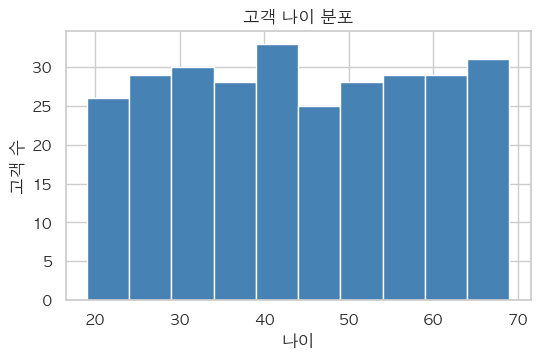

In [5]:
# 방법 1: pyplot 스타일
plt.figure(figsize=(6, 3.5))                 # 그림 크기 (가로, 세로 인치)
plt.hist(df["나이"].dropna(), bins=10, color="steelblue", edgecolor="white")
plt.title("고객 나이 분포")                   # 제목
plt.xlabel("나이")                            # x축 이름
plt.ylabel("고객 수")                          # y축 이름
plt.show()

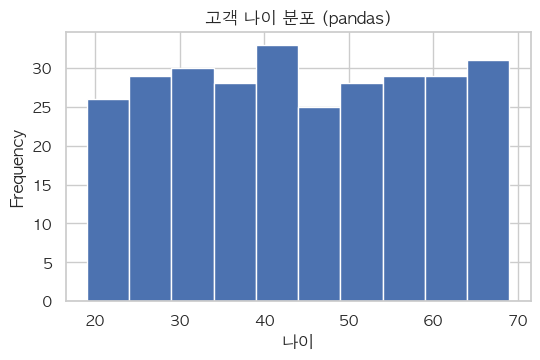

In [6]:
# 방법 2: pandas 내장 plot
df["나이"].plot(kind="hist", bins=10, figsize=(6, 3.5), title="고객 나이 분포 (pandas)")
plt.xlabel("나이")
plt.show()

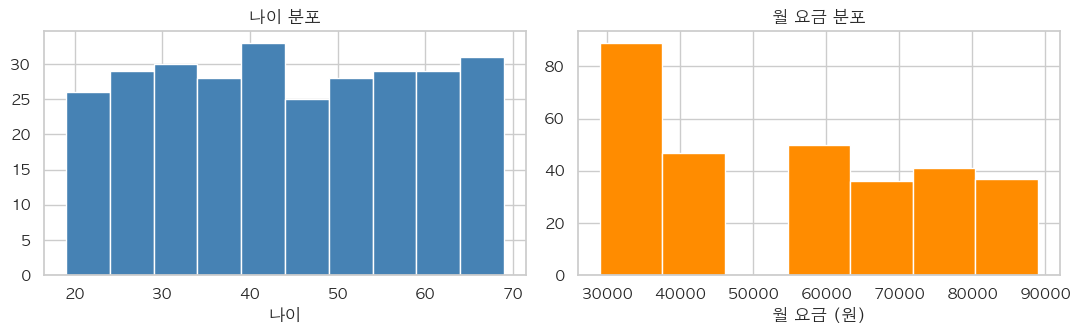

In [7]:
# 방법 3: fig, ax 로 여러 그래프를 한 그림에 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(df["나이"].dropna(), bins=10, color="steelblue", edgecolor="white")
axes[0].set_title("나이 분포")
axes[0].set_xlabel("나이")

axes[1].hist(df["월요금"], bins=7, color="darkorange", edgecolor="white")
axes[1].set_title("월 요금 분포")
axes[1].set_xlabel("월 요금 (원)")

plt.tight_layout()     # 그래프끼리 겹치지 않게
plt.show()

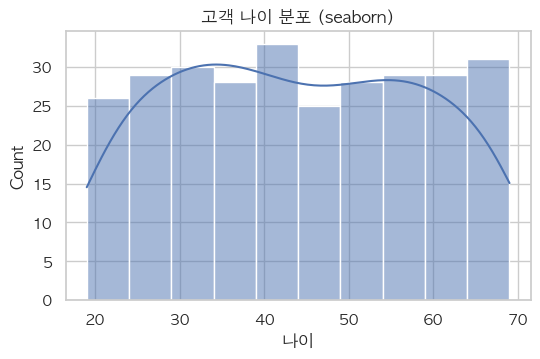

In [8]:
# seaborn: 컬럼명으로 바로 그린다. ax= 를 주면 matplotlib subplot 안에 그려진다.
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.histplot(data=df, x="나이", bins=10, kde=True, ax=ax)   # kde=True: 부드러운 밀도 곡선 추가
ax.set_title("고객 나이 분포 (seaborn)")
plt.show()

In [9]:
# 그림 파일로 저장: plt.show() 이전에 savefig 를 호출한다
plt.figure(figsize=(5, 3))
plt.hist(df["나이"].dropna(), bins=10)
plt.title("저장 테스트")
plt.savefig(f"{DATA_DIR}/age_hist.png", dpi=100, bbox_inches="tight")
plt.close()      # 화면에 띄우지 않고 닫기
print("저장됨:", os.path.exists(f"{DATA_DIR}/age_hist.png"))
os.remove(f"{DATA_DIR}/age_hist.png")

저장됨: True


---
## 2. 단변량 분석 (변수 하나씩 보기)

### 2.1 수치형 변수: 히스토그램

#### 한 줄 정의
값의 범위를 여러 구간(bin)으로 나누고, 각 구간에 몇 개가 있는지 막대로 그린 그래프.

#### 무엇을 읽는가

| 모양 | 의미 | 조치 (4회차) |
|------|------|------|
| 좌우 대칭 종 모양 | 정규분포에 가까움 | 그대로 사용 |
| 오른쪽 꼬리가 김 (right-skewed) | 소수의 큰 값이 존재 (소득, 사용량, 매출) | 로그 변환, 이상치 확인 |
| 봉우리가 2개 이상 | 서로 다른 그룹이 섞여 있음 | 그룹 변수로 나눠서 보기 |
| 특정 값에 뾰족한 막대 | 기본값·결측 대체값·상한값 | 원인 확인 |

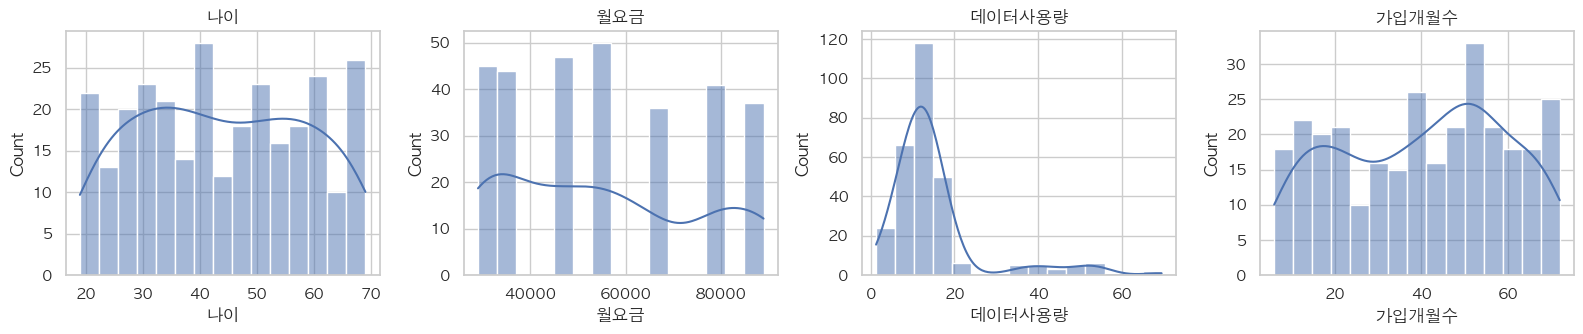

In [10]:
num_cols = ["나이", "월요금", "데이터사용량", "가입개월수"]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, num_cols):
  sns.histplot(data=df, x=col, bins=15, kde=True, ax=ax)
  ax.set_title(col)
plt.tight_layout()
plt.show()

In [11]:
# 왜도(skewness): 0 이면 대칭, 양수면 오른쪽 꼬리, 음수면 왼쪽 꼬리. |skew| > 1 이면 많이 치우친 것
print(df[num_cols].skew().round(2))

나이        0.04
월요금       0.31
데이터사용량    2.50
가입개월수    -0.14
dtype: float64


`데이터사용량` 이 오른쪽으로 크게 치우쳐 있습니다 (skew ≈ 2.5). 이런 변수는 **로그 변환** 하면 대칭에 가까워져 선형 모델이 다루기 쉬워집니다. (4회차에서 실습, 여기서는 효과만 확인)

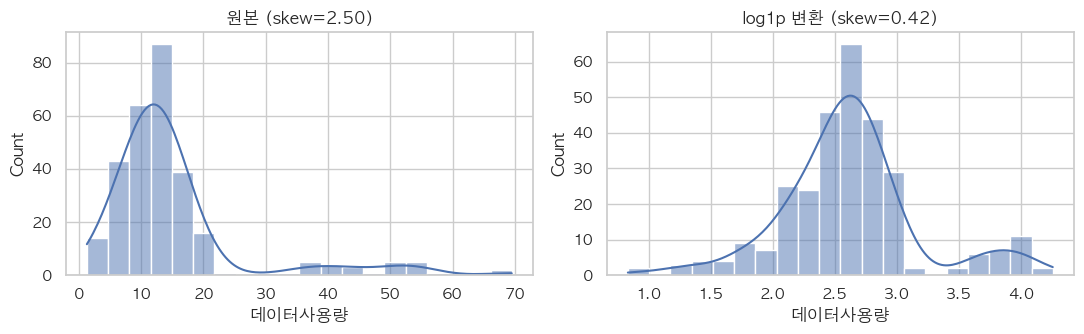

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df["데이터사용량"], bins=20, kde=True, ax=axes[0])
axes[0].set_title(f"원본 (skew={df['데이터사용량'].skew():.2f})")

log_usage = np.log1p(df["데이터사용량"])          # log1p = log(1 + x): 0 이 있어도 안전
sns.histplot(log_usage, bins=20, kde=True, ax=axes[1])
axes[1].set_title(f"log1p 변환 (skew={log_usage.skew():.2f})")
plt.tight_layout()
plt.show()

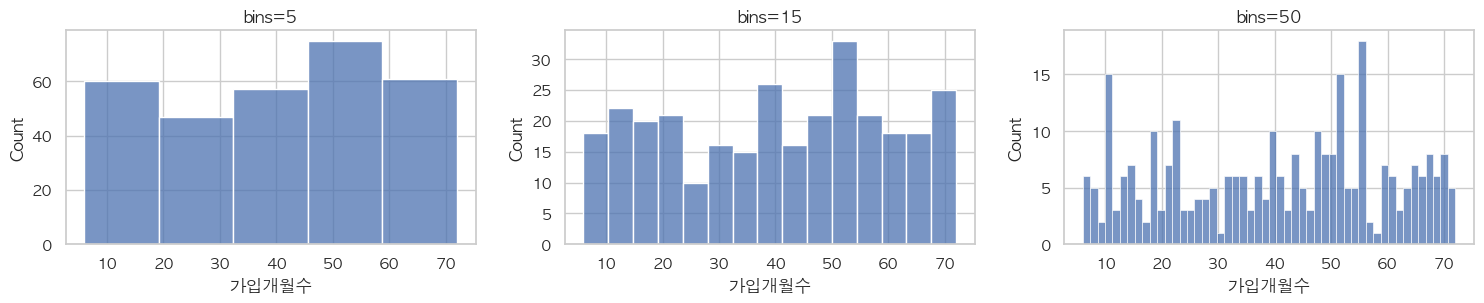

In [13]:
# bins 수에 따라 인상이 달라진다: 너무 적으면 뭉개지고, 너무 많으면 들쭉날쭉. 보통 10~30 사이에서 조절
fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
for ax, b in zip(axes, [5, 15, 50]):
  sns.histplot(df["가입개월수"], bins=b, ax=ax)
  ax.set_title(f"bins={b}")
plt.tight_layout()
plt.show()

### 2.2 수치형 변수: 박스플롯 (상자 그림)

#### 한 줄 정의
데이터를 **사분위수** 로 요약해 상자와 수염으로 그린 그래프. **이상치를 찾는 표준 도구**.

```
   이상치 (점)   ○
                  │        ← 위 수염: Q3 + 1.5×IQR 이내의 최댓값
              ┌───┴───┐
              │       │    ← Q3 (75%)
              │ ───── │    ← 중앙값 (50%)
              │       │    ← Q1 (25%)
              └───┬───┘       IQR = Q3 - Q1 (상자 높이)
                  │        ← 아래 수염: Q1 - 1.5×IQR 이내의 최솟값
```

- 상자 안에 데이터의 **가운데 50%** 가 들어 있다.
- 수염 밖의 점은 **이상치 후보** (4회차에서 IQR 규칙으로 계산하여 처리).
- 중앙선이 상자 가운데에 없으면 치우친 분포.

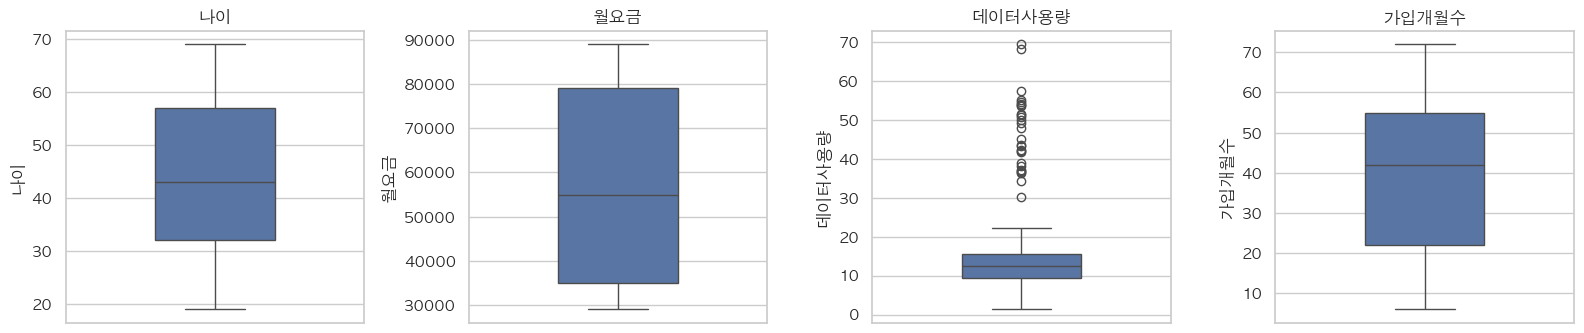

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, num_cols):
  sns.boxplot(data=df, y=col, ax=ax, width=0.4)
  ax.set_title(col)
plt.tight_layout()
plt.show()

In [15]:
# 박스플롯의 숫자 버전: describe() 의 25%, 50%, 75% 와 IQR
q1, q3 = df["데이터사용량"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}, 위 수염 한계={upper:.1f}")
print("이상치 후보 개수:", (df["데이터사용량"] > upper).sum())
print(df.loc[df["데이터사용량"] > upper, ["고객ID", "요금제", "데이터사용량"]].head())

Q1=9.5, Q3=15.4, IQR=5.9, 위 수염 한계=24.4
이상치 후보 개수: 28
     고객ID  요금제  데이터사용량
17  C0018  LTE    57.4
27  C0028  LTE    51.3
51  C0052  LTE    36.9
68  C0069  LTE    43.3
74  C0075   5G    36.3


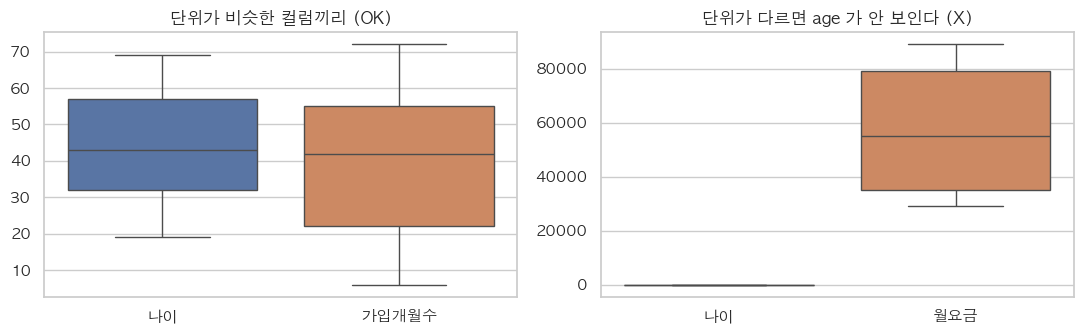

In [16]:
# 여러 수치형을 한 박스플롯에: 단위가 비슷할 때만 의미 있다 (단위가 다르면 큰 값이 그림을 다 차지)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.boxplot(data=df[["나이", "가입개월수"]], ax=axes[0])
axes[0].set_title("단위가 비슷한 컬럼끼리 (OK)")
sns.boxplot(data=df[["나이", "월요금"]], ax=axes[1])
axes[1].set_title("단위가 다르면 age 가 안 보인다 (X)")
plt.tight_layout()
plt.show()

### 2.3 범주형 변수: 막대그래프 (`countplot`)

- 범주별 **개수** 를 막대로 그린다. `value_counts()` 의 그림 버전.
- `order=` 로 막대 순서를 지정한다. (빈도순으로 정렬하면 읽기 쉽다)
- 원그래프(pie)는 비율 비교가 어려워 **분석용으로는 권장하지 않지만**, 시험에서 요구하면 `plot(kind="pie")` 로 그린다.

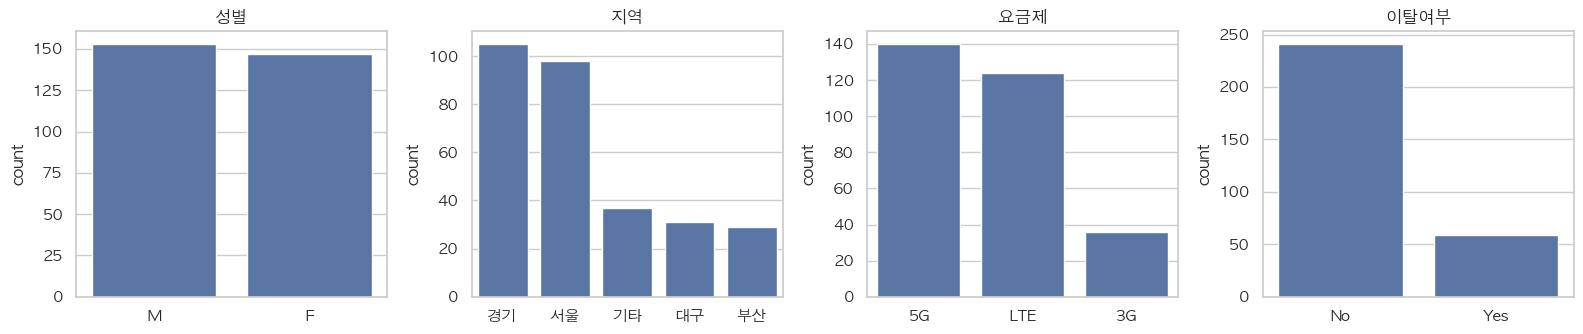

In [17]:
cat_cols = ["성별", "지역", "요금제", "이탈여부"]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, cat_cols):
  order = df[col].value_counts().index            # 빈도 내림차순
  sns.countplot(data=df, x=col, order=order, ax=ax)
  ax.set_title(col)
  ax.set_xlabel("")
plt.tight_layout()
plt.show()

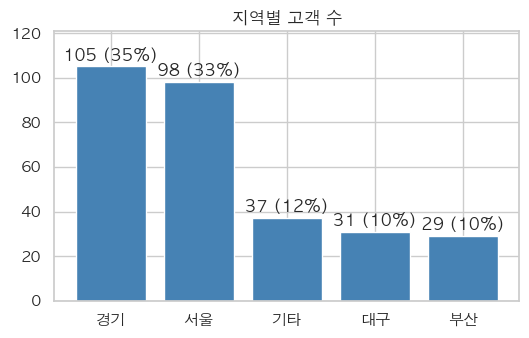

In [18]:
# 막대 위에 숫자 표시 + 비율: 발표 자료에서 자주 요구
counts = df["지역"].value_counts()

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(counts.index, counts.values, color="steelblue")
ax.bar_label(bars, labels=[f"{v} ({v / len(df):.0%})" for v in counts.values], padding=2)
ax.set_title("지역별 고객 수")
ax.set_ylim(0, counts.max() * 1.15)
plt.show()

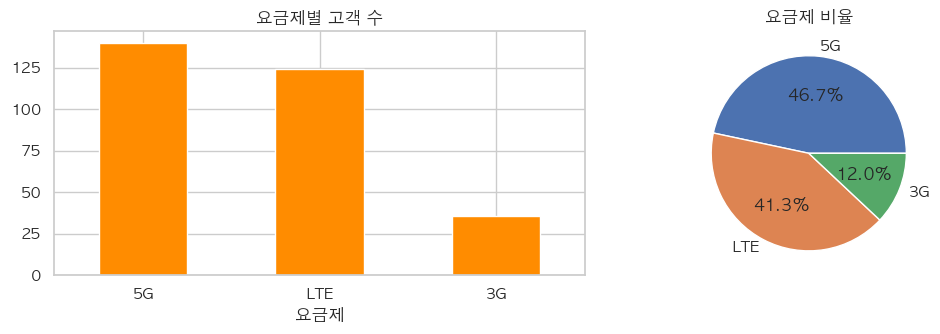

In [19]:
# pandas 로 그리기 (value_counts -> plot) 와 원그래프
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df["요금제"].value_counts().plot(kind="bar", ax=axes[0], color="darkorange", rot=0, title="요금제별 고객 수")
df["요금제"].value_counts().plot(kind="pie", ax=axes[1], autopct="%.1f%%", title="요금제 비율", ylabel="")
plt.tight_layout()
plt.show()

### 2.4 수치형 변수를 범주로 바꿔 보기

나이처럼 연속값도 **구간으로 묶으면** 범주형처럼 막대로 볼 수 있습니다. (`pd.cut` 은 4회차 구간화에서 자세히)

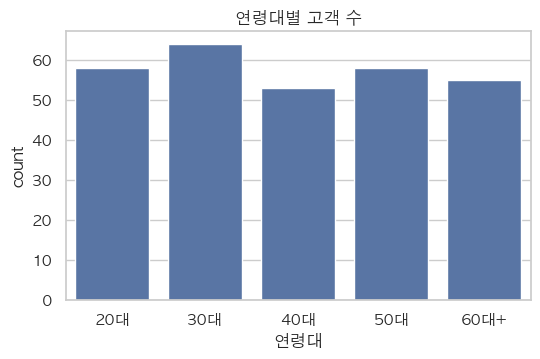

In [20]:
age_bins = [0, 29, 39, 49, 59, 100]
age_labels = ["20대", "30대", "40대", "50대", "60대+"]
df["연령대"] = pd.cut(df["나이"], bins=age_bins, labels=age_labels)

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.countplot(data=df, x="연령대", ax=ax)
ax.set_title("연령대별 고객 수")
plt.show()

### 📝 시험 출제 포인트 (2장)

- "`나이` 컬럼의 히스토그램을 그리시오" → `plt.hist(df["나이"])` 또는 `sns.histplot(df["나이"])`. **결측이 있어도 seaborn 은 자동 제외**, `plt.hist` 는 `dropna()` 필요.
- "`월요금` 의 박스플롯을 그려 이상치를 확인하시오" → `sns.boxplot(y=df["월요금"])`
- "`요금제` 별 고객 수를 막대그래프로" → `sns.countplot(x="요금제", data=df)`
- 그래프 문항은 보통 **제목(`plt.title`)·축 이름(`plt.xlabel`)** 을 요구합니다. `plt.show()` 로 마무리합니다.
- 분포의 치우침 판단 → `df["col"].skew()`

### ⚠️ 자주 하는 실수 (2장)

- **`plt.show()` 를 셀 중간에 호출**: 그 시점에 그림이 닫혀서 이후 `plt.title()` 이 빈 그림에 적용됩니다. 꾸미기를 다 한 뒤 **마지막에** `show()`.
- **`countplot` 과 `barplot` 혼동**: `countplot` 은 개수(y 지정 안 함), `barplot` 은 범주별 **수치의 평균** (y 필요).
- **`histplot` 에 범주형 컬럼**: 문자열 컬럼은 `countplot` 을 씁니다.
- **단위가 다른 컬럼을 한 박스플롯에**: 작은 단위 컬럼이 납작해져 보이지 않습니다. subplot 으로 나누거나 스케일링(4회차) 후 비교합니다.

---
## 3. 이변량 분석 (두 변수의 관계 보기)

### 3.1 수치 vs 수치: 산점도와 상관계수

#### 산점도 (scatter plot)
한 점이 한 행. 점들이 **오른쪽 위로 모이면 양의 관계**, 오른쪽 아래면 음의 관계, 둥글게 퍼지면 관계 없음.

#### 상관계수 (correlation coefficient, 피어슨 r)

| 값 | 해석 |
|------|------|
| +1 | 완벽한 양의 **직선** 관계 |
| 0 | 직선 관계 없음 (곡선 관계는 있을 수 있음!) |
| −1 | 완벽한 음의 직선 관계 |
| 경험적 기준 | \|r\| < 0.3 약함, 0.3~0.7 중간, > 0.7 강함 |

> **상관 ≠ 인과**: 아이스크림 판매량과 익사 사고는 상관이 높지만 원인은 "여름" 입니다. EDA 에서 찾은 상관은 "**모델에 쓸 만한 변수**" 의 후보이지 원인이 아닙니다.

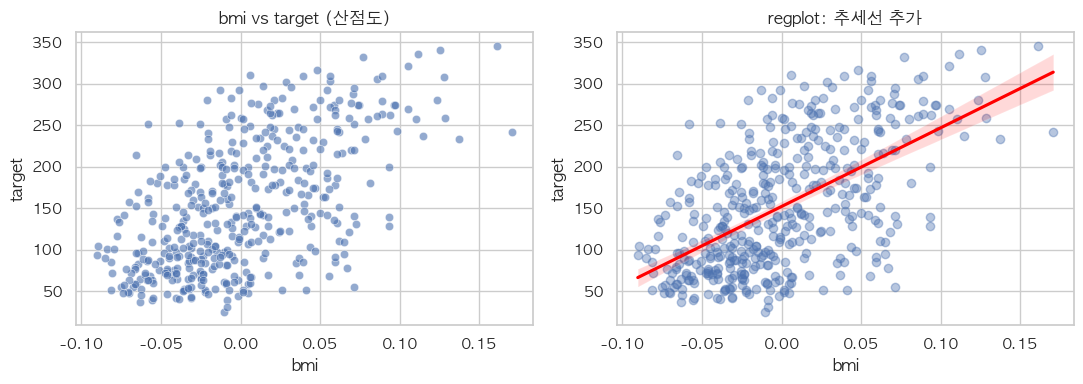

bmi-target 상관계수: 0.586


In [21]:
# 당뇨병 데이터: bmi(체질량지수) 와 target(1년 뒤 진행도) 의 관계
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(data=diabetes, x="bmi", y="target", alpha=0.6, ax=axes[0])
axes[0].set_title("bmi vs target (산점도)")

sns.regplot(data=diabetes, x="bmi", y="target", scatter_kws={"alpha": 0.4}, line_kws={"color": "red"}, ax=axes[1])
axes[1].set_title("regplot: 추세선 추가")
plt.tight_layout()
plt.show()

print("bmi-target 상관계수:", round(diabetes["bmi"].corr(diabetes["target"]), 3))

In [22]:
# 상관 행렬: 모든 수치형 쌍의 상관계수를 한 번에
corr = diabetes.corr()
corr.round(2)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,1.00,0.17,0.19,0.34,0.26,0.22,-0.08,0.20,0.27,0.30,0.19
sex,0.17,1.00,0.09,0.24,0.04,0.14,-0.38,0.33,0.15,0.21,0.04
bmi,0.19,0.09,1.00,0.40,0.25,0.26,-0.37,0.41,0.45,0.39,0.59
bp,0.34,0.24,0.40,1.00,0.24,0.19,-0.18,0.26,0.39,0.39,0.44
s1,0.26,0.04,0.25,0.24,1.00,0.90,0.05,0.54,0.52,0.33,0.21
s2,0.22,0.14,0.26,0.19,0.90,1.00,-0.20,0.66,0.32,0.29,0.17
s3,-0.08,-0.38,-0.37,-0.18,0.05,-0.20,1.00,-0.74,-0.40,-0.27,-0.39
s4,0.20,0.33,0.41,0.26,0.54,0.66,-0.74,1.00,0.62,0.42,0.43
s5,0.27,0.15,0.45,0.39,0.52,0.32,-0.40,0.62,1.00,0.46,0.57
s6,0.30,0.21,0.39,0.39,0.33,0.29,-0.27,0.42,0.46,1.00,0.38


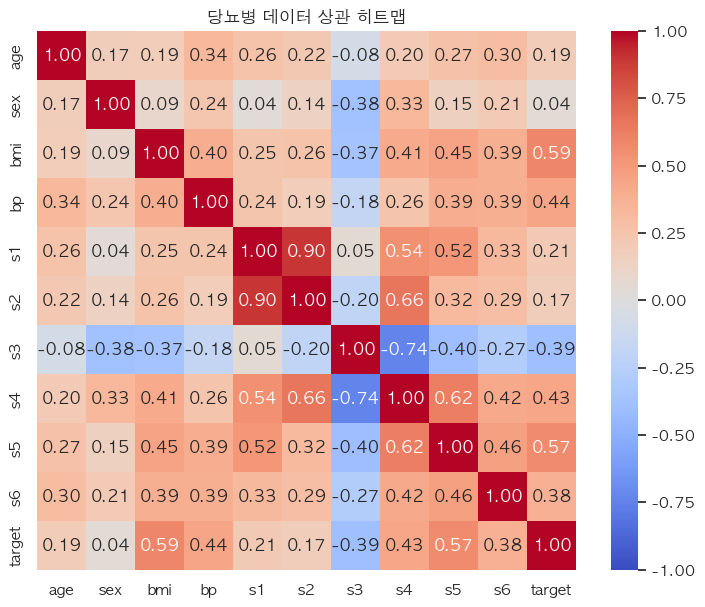

In [23]:
# 상관 히트맵: 시험 단골. annot=True(숫자 표시), fmt(소수 자리), cmap(색), vmin/vmax(색 범위 고정)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("당뇨병 데이터 상관 히트맵")
plt.show()

bmi    0.586
s5     0.566
bp     0.441
s4     0.430
s6     0.382
s1     0.212
age    0.188
s2     0.174
sex    0.043
s3    -0.395
Name: target, dtype: float64


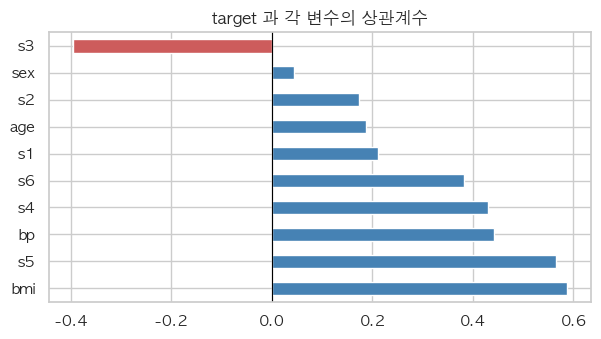

In [24]:
# 타깃과의 상관만 뽑아 정렬: "어떤 변수가 예측에 쓸모 있나" 의 첫 힌트
target_corr = corr["target"].drop("target").sort_values(ascending=False)
print(target_corr.round(3))

fig, ax = plt.subplots(figsize=(7, 3.5))
target_corr.plot(kind="barh", ax=ax, color=np.where(target_corr > 0, "steelblue", "indianred"))
ax.set_title("target 과 각 변수의 상관계수")
ax.axvline(0, color="black", linewidth=0.8)
plt.show()

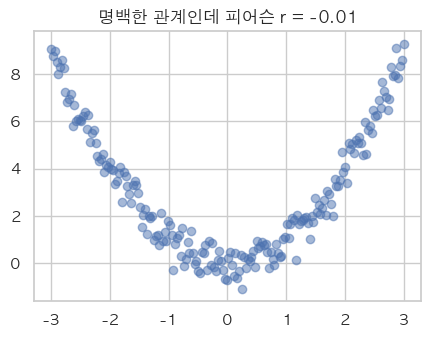

In [25]:
# 상관계수 0 이어도 관계가 있을 수 있다: 곡선 관계 예시 (피어슨 r 은 직선만 잡는다)
x = np.linspace(-3, 3, 200)
y_curve = x ** 2 + np.random.default_rng(0).normal(0, 0.5, 200)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.scatter(x, y_curve, alpha=0.5)
ax.set_title(f"명백한 관계인데 피어슨 r = {np.corrcoef(x, y_curve)[0, 1]:.2f}")
plt.show()

In [26]:
# 스피어만 상관: 순위 기반이라 단조(계속 증가/감소) 관계면 곡선이어도 잡는다. 이상치에도 강함
x_mono = np.linspace(0, 5, 100)
y_mono = np.exp(x_mono)
print("지수 관계 - 피어슨 :", round(pd.Series(x_mono).corr(pd.Series(y_mono)), 3))
print("지수 관계 - 스피어만:", round(pd.Series(x_mono).corr(pd.Series(y_mono), method="spearman"), 3))

지수 관계 - 피어슨 : 0.856
지수 관계 - 스피어만: 1.0


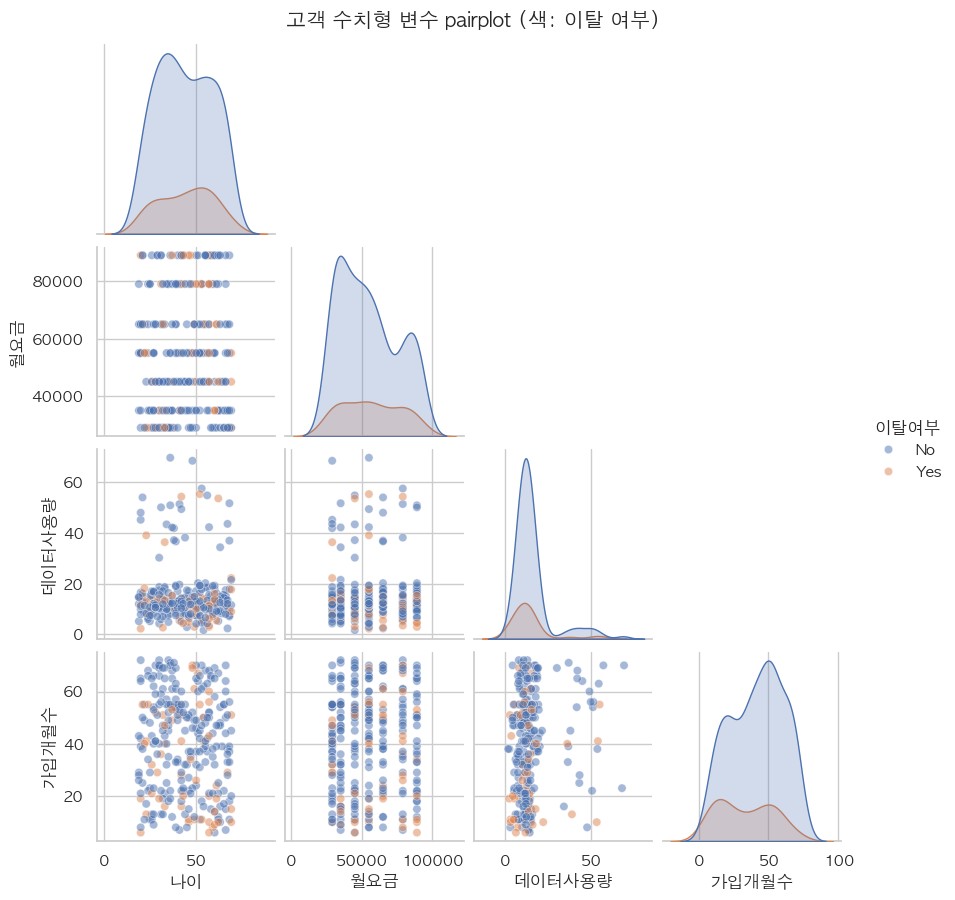

In [27]:
# pairplot: 수치형 여러 쌍의 산점도 + 대각선에 분포. 컬럼이 5개 이하일 때 유용 (많으면 느리고 안 보임)
sns.pairplot(df[num_cols + ["이탈여부"]].dropna(), hue="이탈여부", height=2.2, corner=True, plot_kws={"alpha": 0.5})
plt.suptitle("고객 수치형 변수 pairplot (색: 이탈 여부)", y=1.02)
plt.show()

### 3.2 범주 vs 수치: 그룹별 분포 비교

| 그래프 | 보여주는 것 | 함수 |
|------|------|------|
| 그룹별 박스플롯 | 그룹마다 분포 전체 (중앙값, 퍼짐, 이상치) | `sns.boxplot(x=범주, y=수치)` |
| 평균 막대 | 그룹별 **평균** + 신뢰구간(검은 선) | `sns.barplot(x=범주, y=수치)` |
| 바이올린 | 박스플롯 + 밀도 곡선 | `sns.violinplot` |
| 숫자 | 그룹별 통계표 | `df.groupby(범주)[수치].describe()` |

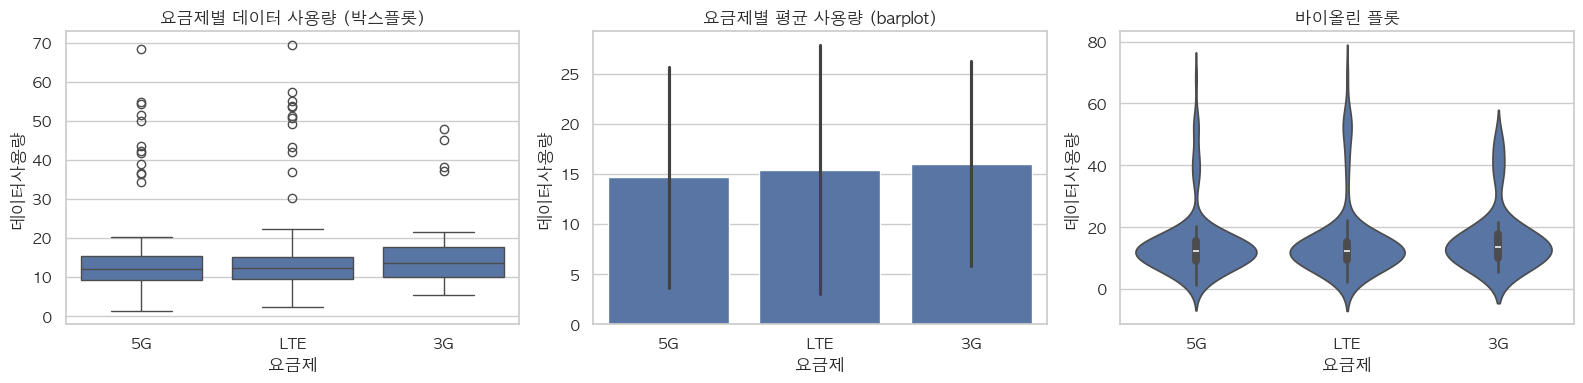

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df, x="요금제", y="데이터사용량", ax=axes[0])
axes[0].set_title("요금제별 데이터 사용량 (박스플롯)")

sns.barplot(data=df, x="요금제", y="데이터사용량", errorbar="sd", ax=axes[1])   # 막대=평균, 선=표준편차
axes[1].set_title("요금제별 평균 사용량 (barplot)")

sns.violinplot(data=df, x="요금제", y="데이터사용량", ax=axes[2])
axes[2].set_title("바이올린 플롯")
plt.tight_layout()
plt.show()

In [29]:
# 그림의 숫자 버전
df.groupby("요금제")["데이터사용량"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
요금제,,,,,,,,
3G,36.0,16.0,10.3,5.4,10.1,13.6,17.7,47.9
5G,136.0,14.6,11.0,1.3,9.2,12.1,15.4,68.3
LTE,120.0,15.4,12.4,2.4,9.4,12.2,15.2,69.5


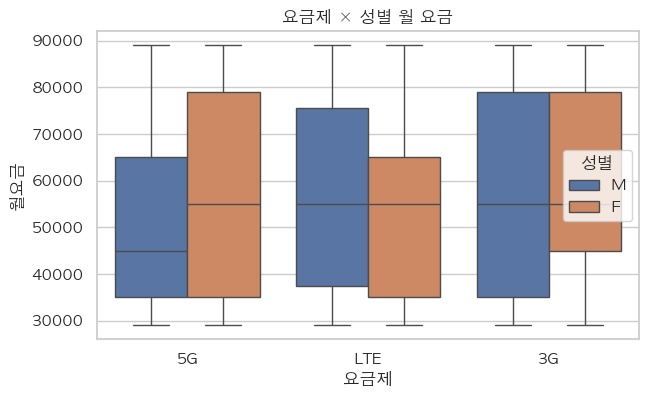

In [30]:
# hue 로 세 번째 변수 추가: 요금제별 사용량을 성별로 나눠 보기
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="요금제", y="월요금", hue="성별", ax=ax)
ax.set_title("요금제 × 성별 월 요금")
plt.show()

### 3.3 범주 vs 범주: 교차표와 비율

두 범주형 변수의 관계는 **교차표(crosstab)** 로 세고, **행 기준 비율** 로 비교합니다. (2회차 `crosstab` 복습)

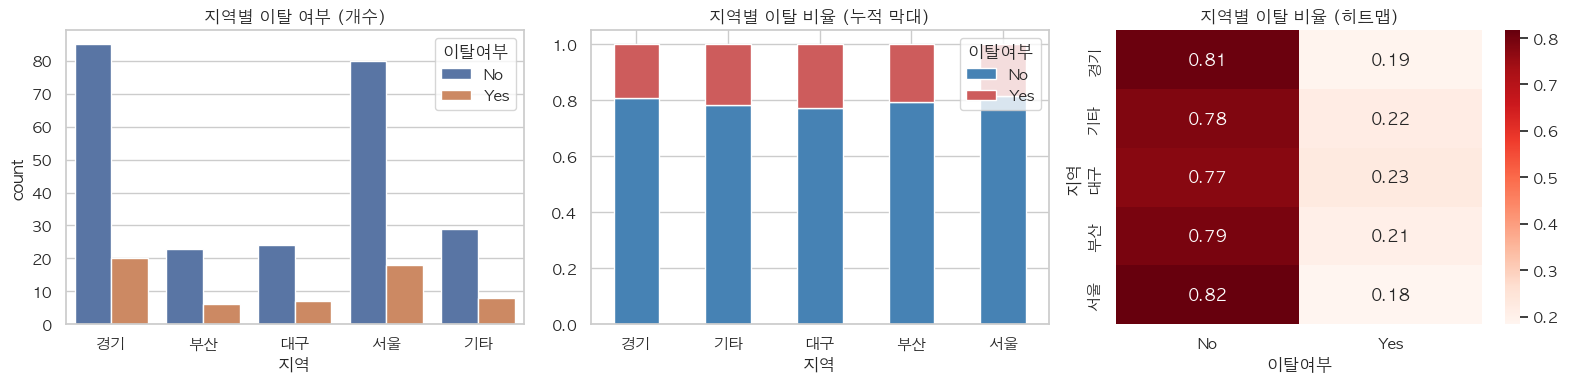

In [31]:
ct = pd.crosstab(df["지역"], df["이탈여부"])
ct_ratio = pd.crosstab(df["지역"], df["이탈여부"], normalize="index")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, x="지역", hue="이탈여부", ax=axes[0])
axes[0].set_title("지역별 이탈 여부 (개수)")

ct_ratio.plot(kind="bar", stacked=True, ax=axes[1], rot=0, color=["steelblue", "indianred"])
axes[1].set_title("지역별 이탈 비율 (누적 막대)")
axes[1].legend(title="이탈여부", loc="upper right")

sns.heatmap(ct_ratio, annot=True, fmt=".2f", cmap="Reds", ax=axes[2])
axes[2].set_title("지역별 이탈 비율 (히트맵)")
plt.tight_layout()
plt.show()

### 3.4 타깃 중심 EDA

지금까지의 도구를 **예측 대상(y)** 에 집중해서 씁니다. 여기서 나오는 그림이 곧 "어떤 변수를 모델에 넣을까" 의 근거가 됩니다.

#### 분류 타깃 (`이탈여부`): 타깃 값별로 각 변수의 분포를 겹쳐 본다

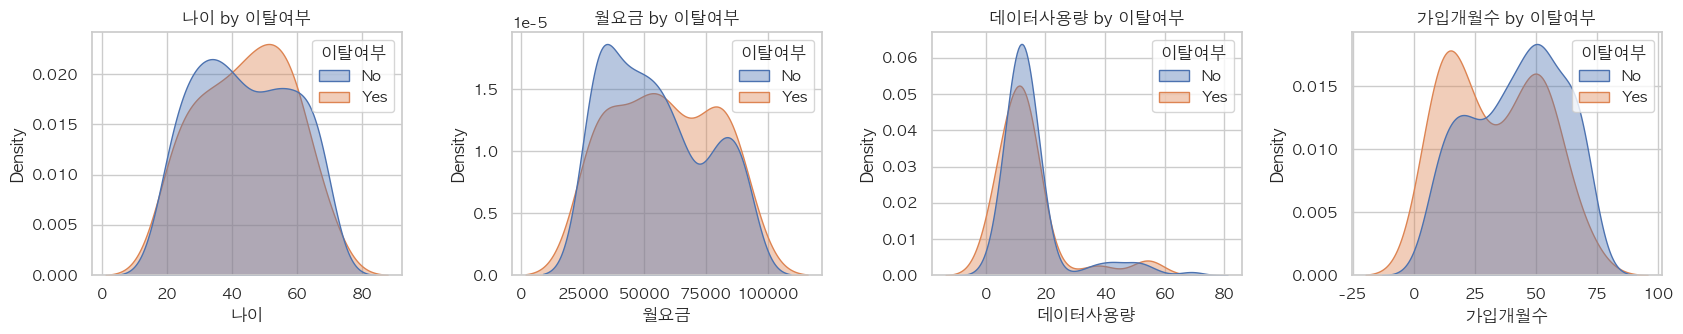

In [32]:
# 수치형 변수: 이탈여부 별 분포를 겹쳐 그린다 -> 두 분포가 많이 다를수록 유용한 변수
fig, axes = plt.subplots(1, 4, figsize=(17, 3.5))
for ax, col in zip(axes, num_cols):
  sns.kdeplot(data=df, x=col, hue="이탈여부", fill=True, common_norm=False, alpha=0.4, ax=ax)
  ax.set_title(f"{col} by 이탈여부")
plt.tight_layout()
plt.show()

In [33]:
# 같은 내용을 숫자로: 이탈여부 별 평균 비교
df.groupby("이탈여부")[num_cols].mean().round(1)

,나이,월요금,데이터사용량,가입개월수
이탈여부,,,,
No,43.8,54626.6,15.4,41.9
Yes,44.2,57915.3,14.0,33.3


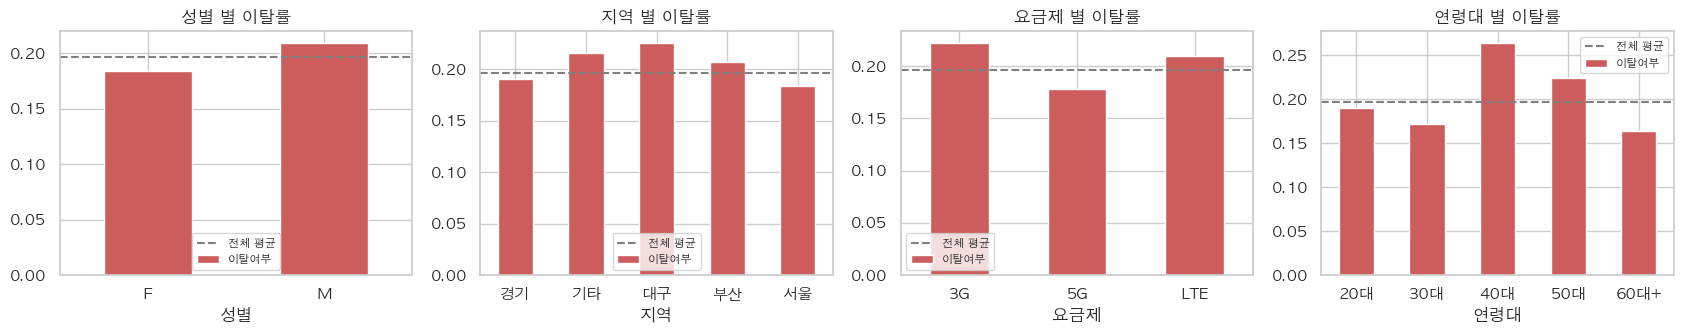

In [34]:
# 범주형 변수: 범주별 이탈률 -> 범주 간 이탈률 차이가 클수록 유용한 변수
fig, axes = plt.subplots(1, 4, figsize=(17, 3.5))
for ax, col in zip(axes, ["성별", "지역", "요금제", "연령대"]):
  rate = df.groupby(col, observed=True)["이탈여부"].apply(lambda s: (s == "Yes").mean())
  rate.plot(kind="bar", ax=ax, rot=0, color="indianred")
  ax.axhline((df["이탈여부"] == "Yes").mean(), color="gray", linestyle="--", label="전체 평균")
  ax.set_title(f"{col} 별 이탈률")
  ax.set_ylabel("")
  ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [35]:
# 가입 기간을 구간으로 나눠 이탈률 확인: "1년 미만 고객이 많이 이탈한다" 가설
df["가입기간구간"] = pd.cut(df["가입개월수"], bins=[-1, 11, 23, 47, 200], labels=["<1년", "1~2년", "2~4년", "4년+"])
tenure_rate = df.groupby("가입기간구간", observed=True)["이탈여부"].apply(lambda s: (s == "Yes").mean()).round(3)
print(tenure_rate)

가입기간구간
<1년     0.429
1~2년    0.226
2~4년    0.161
4년+     0.159
Name: 이탈여부, dtype: float64


#### 회귀 타깃 (`target`): 타깃과 각 변수의 산점도를 한 번에

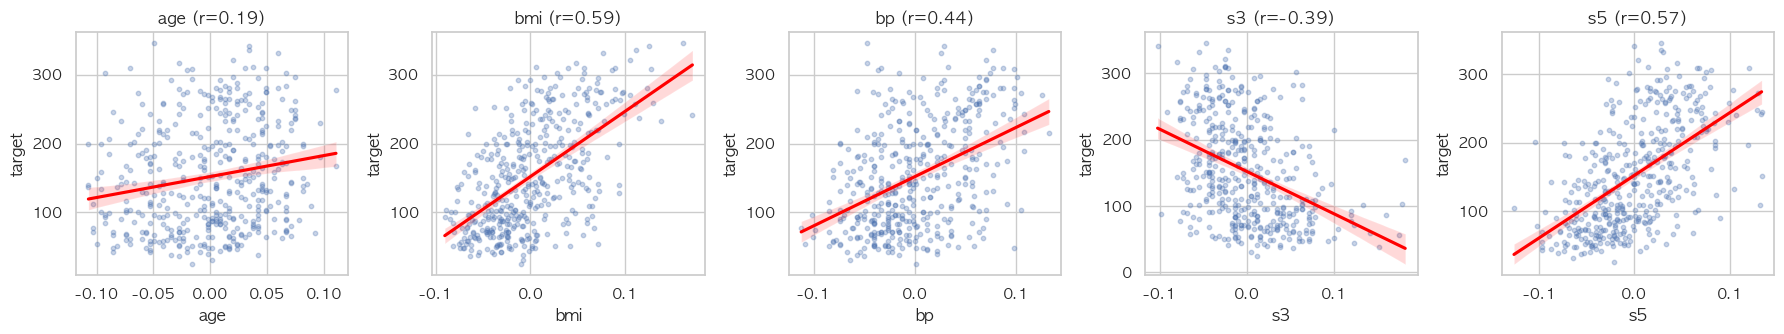

In [36]:
features = ["age", "bmi", "bp", "s3", "s5"]
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, col in zip(axes, features):
  sns.regplot(data=diabetes, x=col, y="target", scatter_kws={"alpha": 0.3, "s": 10}, line_kws={"color": "red"}, ax=ax)
  ax.set_title(f"{col} (r={diabetes[col].corr(diabetes['target']):.2f})")
plt.tight_layout()
plt.show()

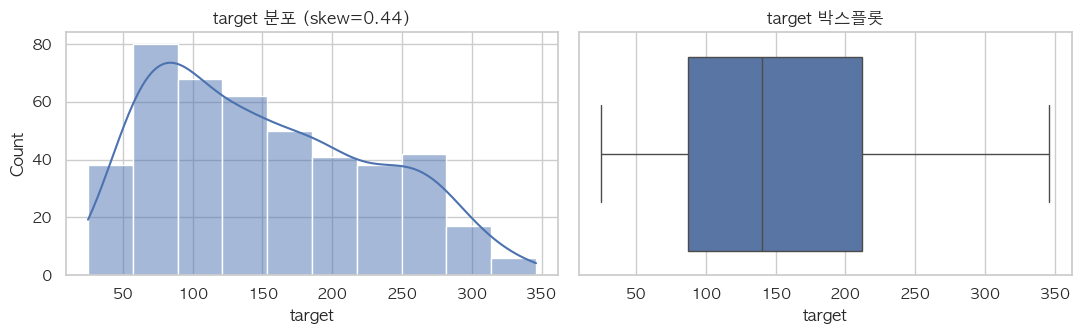

In [37]:
# 회귀 타깃 자체의 분포도 확인한다: 치우쳐 있으면 로그 변환을 고려
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(diabetes["target"], kde=True, ax=axes[0])
axes[0].set_title(f"target 분포 (skew={diabetes['target'].skew():.2f})")
sns.boxplot(x=diabetes["target"], ax=axes[1])
axes[1].set_title("target 박스플롯")
plt.tight_layout()
plt.show()

### 3.5 시계열 데이터 보기

날짜가 있는 데이터는 **선 그래프** 로 흐름을 보고, 요일·월 같은 주기를 확인합니다.

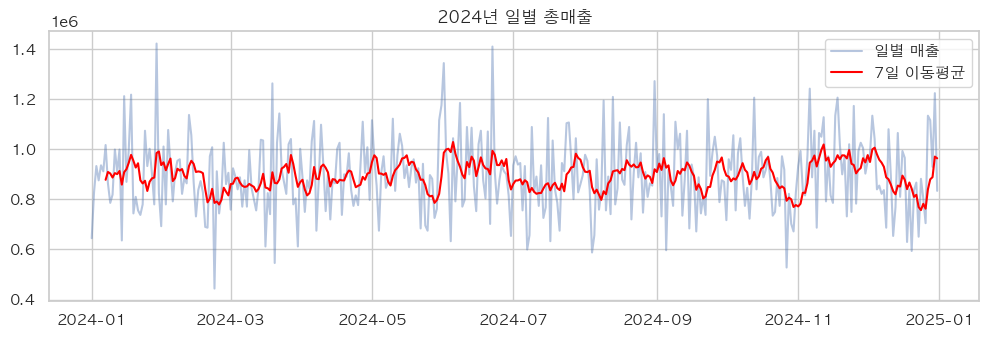

In [38]:
# 일별 총매출 선 그래프 + 7일 이동평균 (노이즈를 줄여 추세를 본다)
daily = sales.groupby("날짜")["매출액"].sum()
rolling7 = daily.rolling(window=7).mean()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(daily.index, daily.values, alpha=0.4, label="일별 매출")
ax.plot(rolling7.index, rolling7.values, color="red", label="7일 이동평균")
ax.set_title("2024년 일별 총매출")
ax.legend()
plt.show()

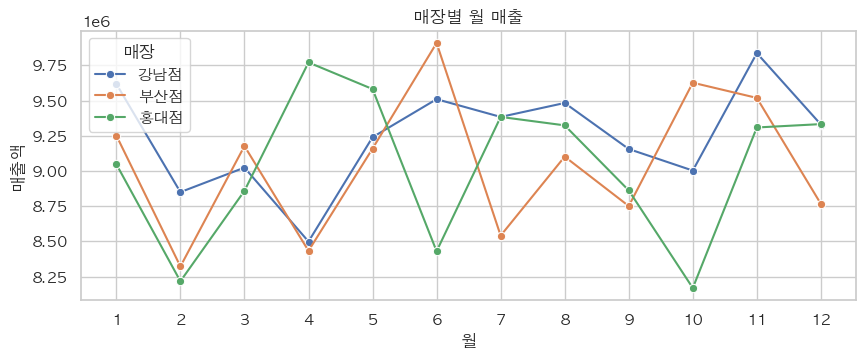

In [39]:
# 매장별 월 매출 추이: lineplot 의 hue
sales["월"] = sales["날짜"].dt.month
monthly_store = sales.groupby(["월", "매장"])["매출액"].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 3.5))
sns.lineplot(data=monthly_store, x="월", y="매출액", hue="매장", marker="o", ax=ax)
ax.set_title("매장별 월 매출")
ax.set_xticks(range(1, 13))
plt.show()

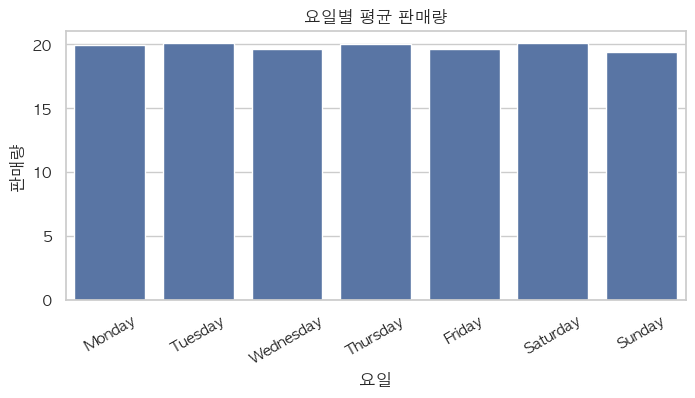

In [40]:
# 요일 패턴: 주말 효과가 있는지
sales["요일"] = sales["날짜"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(data=sales, x="요일", y="판매량", order=weekday_order, errorbar=None, ax=ax)
ax.set_title("요일별 평균 판매량")
ax.tick_params(axis="x", rotation=30)
plt.show()

### 📝 시험 출제 포인트 (3장)

- "수치형 변수 간 상관계수를 구하고 히트맵으로 시각화" → `corr = df.corr(numeric_only=True)` 후 `sns.heatmap(corr, annot=True)`. **문자열 컬럼이 있으면 `numeric_only=True`** 가 필요합니다.
- "`target` 과 상관이 가장 높은 변수" → `corr["target"].drop("target").abs().idxmax()`
- "`요금제` 별 `월요금` 의 박스플롯" → `sns.boxplot(x="요금제", y="월요금", data=df)`
- "`이탈여부` 에 따른 `가입개월수` 분포 비교" → `sns.histplot(data=df, x="가입개월수", hue="이탈여부")` 또는 `kdeplot`
- "산점도로 두 변수의 관계 확인" → `plt.scatter(df["a"], df["b"])` 또는 `sns.scatterplot`

### ⚠️ 자주 하는 실수 (3장)

- **`df.corr()` 에 문자열 컬럼이 있어 에러**: pandas 2.0 부터 문자열이 있으면 `ValueError`. `df.corr(numeric_only=True)` 또는 `df.select_dtypes("number").corr()`.
- **상관이 낮다고 변수를 버림**: 피어슨은 직선 관계만 봅니다. 트리 모델(6회차)은 비선형 관계도 잡으므로, EDA 의 상관은 참고일 뿐 최종 판단은 모델 성능으로 합니다.
- **`hue` 컬럼에 결측**: 결측 행은 그림에서 조용히 빠집니다. 결측 수를 먼저 확인합니다.
- **`barplot` 의 검은 선을 오차로 오해**: 기본은 95% 신뢰구간입니다. 필요 없으면 `errorbar=None`.
- **`pairplot` 을 컬럼 20개에 실행**: 매우 느리고 읽을 수 없습니다. 타깃과 상관 높은 4~5개만 고릅니다.

---
## 4. 발견을 가설과 계획으로 바꾸기

EDA 는 **그림을 그리는 것이 목적이 아니라, 다음 단계의 결정을 내리는 것** 이 목적입니다. 오늘 고객 데이터에서 본 것을 정리하면:

| 발견 (그림) | 가설 | 4회차 전처리 / 5회차 모델링 계획 |
|------|------|------|
| `데이터사용량` 오른쪽 치우침, 이상치 존재 | 소수의 헤비유저가 있다 | 로그 변환 또는 IQR 로 이상치 처리 |
| `나이`, `데이터사용량` 에 결측 | 입력 누락 | 중앙값 대체 (분포가 치우친 컬럼은 평균보다 중앙값) |
| 가입 1년 미만 이탈률(약 43%)이 전체 평균(약 20%)의 2배 이상 | **신규 고객이 이탈 위험** | `가입개월수` 는 핵심 변수, `가입기간구간` 파생 변수 고려 |
| `요금제` 별 이탈률이 `3G` 22%, `LTE` 21%, `5G` 18% 로 차이가 작음 | 요금제는 이탈과 관련이 약할 수 있음 | 원-핫 인코딩하여 넣어 보고 성능 기여 확인 |
| `성별`(18~21%)·`지역`(18~23%) 별 이탈률 차이가 작음 | 예측력이 낮을 수 있음 | 인코딩 후 넣어 보고 성능 차이 없으면 제거 후보 |
| `나이`, `월요금`, `데이터사용량` 은 이탈 여부별 평균 차이가 작음 | 예측력이 낮을 수 있음 | 넣어 보고 성능 차이 없으면 제거 후보 |
| `월요금` 과 `데이터사용량` 상관 ≈ 0 | 요금과 사용량이 따로 논다 | 둘 중 하나가 유용하면 다른 하나도 독립적으로 검토 |
| `이탈여부` 비율 약 20% : 80% | 불균형 데이터 | 정확도만 보지 말고 재현율·F1 확인 (5회차) |

> 시험에서는 이런 표를 쓰라고 하진 않지만, **문항의 흐름이 정확히 이 순서** 입니다. 시각화 문항 → 전처리 문항 → 모델링 문항이 같은 데이터로 이어지므로, EDA 에서 본 것을 기억해 두면 뒤 문항이 쉬워집니다.

---
## 5. 종합 실습

`data/customers.csv` 와 당뇨병 데이터를 다시 읽어 시작합니다. 각 그래프에는 **제목** 을 붙이세요.

In [41]:
df = pd.read_csv(f"{DATA_DIR}/customers.csv", dtype={"우편번호": str}, parse_dates=["가입일"])
diabetes = load_diabetes(as_frame=True).frame
print(df.shape, diabetes.shape)

(300, 11) (442, 11)


### 문제 1. 히스토그램과 왜도

`가입개월수` 의 히스토그램(bins=20)을 그리고 제목을 붙이시오. 왜도를 소수 둘째 자리까지 출력하시오.

In [42]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
plt.figure(figsize=(6, 3.5))
sns.histplot(df["가입개월수"], bins=20)
plt.title("가입 기간 분포")
plt.show()
print(round(df["가입개월수"].skew(), 2))
```

</details>

### 문제 2. 그룹별 박스플롯

`지역` 별 `월요금` 의 박스플롯을 그리시오. 어느 지역의 중앙값이 가장 높은지 `groupby` 로 확인하여 출력하시오.

In [43]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
plt.figure(figsize=(7, 3.5))
sns.boxplot(data=df, x="지역", y="월요금")
plt.title("지역별 월 요금")
plt.show()
median_by_region = df.groupby("지역")["월요금"].median()
print(median_by_region.idxmax(), median_by_region.max())
```

</details>

### 문제 3. 상관 히트맵

`df` 의 수치형 컬럼만 골라 상관 행렬 `corr` 을 만들고, `annot=True` 히트맵으로 그리시오. `가입개월수` 와 상관의 절댓값이 가장 큰 다른 변수 이름을 출력하시오.

In [44]:
# 여기에 코드를 작성하세요
corr = None

<details>
<summary>정답 보기</summary>

```python
corr = df.corr(numeric_only=True)
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("고객 수치형 변수 상관")
plt.show()
print(corr["가입개월수"].drop("가입개월수").abs().idxmax())
```

</details>

### 문제 4. 타깃별 분포 비교

`이탈여부` 값에 따라 `가입개월수` 의 분포가 어떻게 다른지 `histplot(hue=...)` 으로 그리시오. `이탈여부` 별 `가입개월수` 평균을 출력하시오.

In [45]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
plt.figure(figsize=(7, 3.5))
sns.histplot(data=df, x="가입개월수", hue="이탈여부", bins=20, multiple="layer", alpha=0.5)
plt.title("이탈 여부별 가입 기간 분포")
plt.show()
print(df.groupby("이탈여부")["가입개월수"].mean().round(1))
```

</details>

### 문제 5. 범주 × 범주

`요금제` 와 `이탈여부` 의 교차표를 행 기준 비율로 만들어 `q5` 에 저장하고, `countplot(hue=)` 으로 시각화하시오.

In [46]:
# 여기에 코드를 작성하세요
q5 = None

<details>
<summary>정답 보기</summary>

```python
q5 = pd.crosstab(df["요금제"], df["이탈여부"], normalize="index").round(3)
print(q5)
plt.figure(figsize=(6, 3.5))
sns.countplot(data=df, x="요금제", hue="이탈여부")
plt.title("요금제별 이탈 여부")
plt.show()
```

</details>

### 문제 6. 회귀 타깃 EDA

당뇨병 데이터에서 `target` 과 상관이 높은 상위 3개 변수를 구하고, 각각 `target` 과의 산점도를 1행 3열 subplot 으로 그리시오.

In [47]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
top3 = diabetes.corr()["target"].drop("target").abs().sort_values(ascending=False).head(3).index.tolist()
print(top3)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, top3):
  sns.scatterplot(data=diabetes, x=col, y="target", alpha=0.5, ax=ax)
  ax.set_title(f"{col} vs target")
plt.tight_layout()
plt.show()
```

</details>

### 문제 7 (도전). 발견 → 가설

위 그래프들을 바탕으로, 고객 이탈 예측 모델에 **꼭 넣어야 할 변수 2개** 와 **빼도 될 것 같은 변수 1개** 를 근거와 함께 마크다운으로 적으시오.

_(여기에 답을 적어 보세요)_

- 꼭 넣어야 할 변수:  
- 빼도 될 것 같은 변수:  

<details>
<summary>정답 예시</summary>

- **꼭 넣어야 할 변수**: `가입개월수` (1년 미만 그룹의 이탈률 약 43% 로 전체 평균의 2배 이상, 이탈 여부별 평균 차이도 가장 큼), `월요금` (이탈 고객의 평균 요금이 약 3천 원 높음. 차이는 작지만 수치형 중 두 번째 후보).
- **빼도 될 것 같은 변수**: `성별` 또는 `지역` (범주별 이탈률 차이가 3~5%p 로 작음), `나이` (이탈 여부별 평균이 거의 같음). 식별자 `고객ID`, `우편번호` 는 당연히 제외. 단, 최종 판단은 모델 성능 비교로 한다.

</details>

---
## 6. 오늘의 정리

### 핵심 요약

| 주제 | 기억할 것 |
|------|-----------|
| EDA 순서 | 단변량 → 이변량 → 타깃 중심 → 가설 |
| matplotlib | `plt.figure` → 그리기 → `title/xlabel/ylabel/legend` → `plt.show()`. 여러 개는 `plt.subplots(행, 열)` |
| 수치형 한 변수 | `histplot`(분포 모양, `skew()`), `boxplot`(이상치, IQR) |
| 범주형 한 변수 | `countplot(order=)`, `value_counts().plot(kind="bar")` |
| 수치 vs 수치 | `scatterplot`/`regplot`, `corr(numeric_only=True)`, `heatmap(annot=True)` |
| 범주 vs 수치 | `boxplot(x=범주, y=수치)`, `barplot`(평균) |
| 범주 vs 범주 | `crosstab(normalize="index")`, `countplot(hue=)` |
| 타깃 중심 | 분류: `hue=타깃` 으로 분포 겹치기, 범주별 타깃 비율. 회귀: 타깃과의 상관·산점도 |
| 시계열 | `groupby(date)` + `plot`, `rolling().mean()`, `lineplot(hue=)` |
| 상관 ≠ 인과 | 피어슨은 직선 관계만. 곡선은 `spearman` 또는 산점도로 확인 |

### 자기 점검 체크리스트

- [ ] 변수 타입 조합(수치/범주)을 보고 알맞은 그래프를 즉시 고를 수 있다.
- [ ] 히스토그램에서 치우침을 읽고 `skew()` 로 확인할 수 있다.
- [ ] 박스플롯의 상자·수염·점이 각각 무엇인지 설명할 수 있다.
- [ ] `corr()` + `heatmap` 을 그리고 타깃과 상관 높은 변수를 뽑을 수 있다.
- [ ] `hue=` 로 타깃별 분포를 겹쳐 그릴 수 있다.
- [ ] `plt.subplots` 로 여러 그래프를 한 그림에 배치할 수 있다.
- [ ] EDA 결과를 "어떤 변수를 어떻게 전처리할지" 계획으로 바꿀 수 있다.

### 다음 회차 예고 — 4회차: 데이터 전처리하기

- 결측치: `isnull`, `fillna`(평균/중앙값/최빈값/그룹별), `dropna`
- 이상치: IQR 규칙으로 찾고 제거·대체(clip)
- 구간화: `pd.cut`, `pd.qcut`
- 인코딩: `get_dummies`(원-핫), `LabelEncoder`
- 스케일링: `MinMaxScaler` vs `StandardScaler`
- `train_test_split` 과 `stratify` 의 의미
- 오늘 세운 가설(로그 변환, 중앙값 대체, 요금제 인코딩)을 실제 코드로 실행합니다.